# 47. Chebyshev Interpolation

**Part 7: Interpolation**

## Learning objectives

By the end of this lesson you will be able to:

1. State and use the **minimax theorem** for the node polynomial, and verify it attains
   $2^{1-n}$.
2. Compute Chebyshev polynomials two independent ways and know which to use where.
3. Place Chebyshev nodes on any interval, and say what the change of interval costs.
4. Define the **Lebesgue constant** and use it to bound interpolation against best approximation.
5. Measure the two growth rates that explain the whole of lesson 46.
6. Exploit the closed form barycentric weights, which make Chebyshev interpolation $O(n)$.

## Prerequisites

Lesson 46 (the error formula, the node polynomial and the two failures this lesson fixes).
Lesson 44 (the barycentric form, which becomes free here). Lesson 15 (condition numbers, since
the Lebesgue constant is one).

---

## 1. The one theorem

Lesson 46 left one factor under our control: the node polynomial
$w(t) = \prod_i (t - x_i)$. It is **monic** of degree $n$, since expanding gives $t^n$ plus lower
terms. So the question is:

> Among all monic polynomials of degree $n$ on $[-1, 1]$, which has the smallest maximum absolute
> value?

**Chebyshev's answer**: it is $T_n / 2^{n-1}$, and its maximum is exactly $2^{1-n}$.

Since the node polynomial is monic of degree $n$, choosing the nodes to be the **roots of $T_n$**
makes the only controllable factor of the error as small as it can possibly be. That is the whole
lesson, and everything else is consequence.

In [1]:
# Standard setup, the same in every lesson of this course.
import sys, pathlib

_root = pathlib.Path.cwd()
while not (_root / "src" / "nalib").is_dir() and _root != _root.parent:
    _root = _root.parent
sys.path.insert(0, str(_root / "src"))

import numpy as np
import matplotlib.pyplot as plt

SEED = 42                                  # fixed so your numbers match the text
rng = np.random.default_rng(SEED)

np.set_printoptions(precision=6, linewidth=100, suppress=False)
plt.rcParams.update({
    "figure.figsize": (7.5, 4.5), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.3, "font.size": 10,
})

In [2]:
from nalib import chebyshev as cb

print(f"{'n':>4}{'Chebyshev max |w|':>21}{'2^(1-n)':>14}{'agreement':>13}"
      f"{'vs equal':>11}{'vs best random':>16}")
for n in (4, 6, 8, 10, 12, 14):
    out = cb.minimax_property(n, n_random=300, rng=np.random.default_rng(2))
    print(f"{n:>4}{out['chebyshev']:>21.6e}{out['theoretical_minimum']:>14.6e}"
          f"{out['chebyshev_matches_theory']:>13.1e}"
          f"{out['beats_equally_spaced_by']:>10.2f}x{out['beats_random_by']:>15.2f}x")
    assert out["chebyshev_matches_theory"] < 1e-12
    assert out["beats_equally_spaced_by"] > 1.0 and out["beats_random_by"] > 1.0

   n    Chebyshev max |w|       2^(1-n)    agreement   vs equal  vs best random
   4         1.250000e-01  1.250000e-01      2.2e-16      1.58x           1.48x
   6         3.125000e-02  3.125000e-02      2.9e-15      2.22x           2.37x
   8         7.812500e-03  7.812500e-03      1.1e-15      3.64x           3.60x
  10         1.953125e-03  1.953125e-03      6.7e-15      6.45x           5.13x
  12         4.882813e-04  4.882812e-04      5.1e-15     11.93x          11.11x
  14         1.220703e-04  1.220703e-04      2.9e-15     22.71x           6.55x


Three things to notice. The measured maximum agrees with $2^{1-n}$ to $10^{-15}$, so the theorem
is exact and not asymptotic. It beats equally spaced nodes by a factor growing to 22.7 at
fourteen nodes. And it beats the **best of three hundred random node sets** every time, which is
what a theorem saying "smallest" should do.

## 2. The polynomials

$T_0 = 1$, $T_1 = t$, and

$$
T_{k+1}(t) = 2t\,T_k(t) - T_{k-1}(t)
$$

Equivalently, and more usefully,

$$
T_k(\cos\theta) = \cos(k\theta)
$$

The second form makes every property immediate. $|T_k| \le 1$ on $[-1,1]$, because cosine is. It
has $k$ roots at $\cos((2j+1)\pi/2k)$ and $k+1$ extrema of $\pm1$ at $\cos(j\pi/k)$, because
cosine does. And it **equioscillates**, hitting $+1$ and $-1$ alternately, which is precisely the
property that characterises a minimax polynomial.

In [3]:
print(f"{'k':>4}{'recurrence vs cosine':>24}{'max |T_k| on [-1,1]':>23}")
for k in (0, 1, 2, 3, 5, 9, 16, 25):
    out = cb.recurrence_vs_cosine(k)
    grid = np.linspace(-1.0, 1.0, 2001)
    print(f"{k:>4}{out['relative_gap']:>24.2e}{float(np.max(np.abs(cb.recurrence(k, grid)))):>23.12f}")
    assert out["relative_gap"] < 1e-12
    assert float(np.max(np.abs(cb.recurrence(k, grid)))) <= 1.0 + 1e-12

   k    recurrence vs cosine    max |T_k| on [-1,1]
   0                0.00e+00         1.000000000000
   1                2.22e-16         1.000000000000
   2                5.97e-16         1.000000000000
   3                1.33e-15         1.000000000000
   5                2.11e-15         1.000000000000
   9                4.22e-15         1.000000000000
  16                4.43e-15         1.000000000000
  25                1.30e-14         1.000000000000


Two independent computations agreeing to $10^{-15}$, and the bound of 1 attained exactly.

There is a third representation, the power form, and it is included only so that it can be looked
at and not used:

In [4]:
for k in (2, 4, 6, 10):
    coeffs = cb.coefficients(k)
    print(f"T_{k:<2} coefficients, ascending: {np.array2string(coeffs, precision=0)}")
print()
print("the leading coefficient is 2^(k-1), which is why T_k / 2^(k-1) is the monic one")

T_2  coefficients, ascending: [-1.  0.  2.]
T_4  coefficients, ascending: [ 1.  0. -8.  0.  8.]
T_6  coefficients, ascending: [ -1.   0.  18.   0. -48.   0.  32.]
T_10 coefficients, ascending: [-1.e+00  0.e+00  5.e+01  0.e+00 -4.e+02  0.e+00  1.e+03  0.e+00 -1.e+03  0.e+00  5.e+02]

the leading coefficient is 2^(k-1), which is why T_k / 2^(k-1) is the monic one


Evaluating a Chebyshev polynomial through those coefficients would throw away everything the
recurrence and the cosine identity give you, for no gain at all.

## 3. The nodes, and moving them

The **Chebyshev points of the first kind** are the roots of $T_n$:

$$
x_j = \cos\frac{(2j+1)\pi}{2n}, \qquad j = 0, \dots, n-1
$$

The **Chebyshev-Lobatto points**, or points of the second kind, are the extrema:

$$
x_j = \cos\frac{j\pi}{n-1}, \qquad j = 0, \dots, n-1
$$

which include both endpoints. A practical code usually wants those, so the interpolant is defined
on the closed interval without extrapolating, and so a fast cosine transform applies.

In [5]:
for n in (5, 9):
    print(f"n = {n}")
    print(f"  roots of T_n  : {np.array2string(cb.nodes(n), precision=4)}")
    print(f"  Lobatto points: {np.array2string(cb.extrema_nodes(n), precision=4)}")
print()
print("both cluster toward the ends, which is exactly where lesson 46's node polynomial was worst")

n = 5
  roots of T_n  : [-9.5106e-01 -5.8779e-01  6.1232e-17  5.8779e-01  9.5106e-01]
  Lobatto points: [-1.0000e+00 -7.0711e-01  6.1232e-17  7.0711e-01  1.0000e+00]
n = 9
  roots of T_n  : [-9.8481e-01 -8.6603e-01 -6.4279e-01 -3.4202e-01  6.1232e-17  3.4202e-01  6.4279e-01  8.6603e-01
  9.8481e-01]
  Lobatto points: [-1.0000e+00 -9.2388e-01 -7.0711e-01 -3.8268e-01  6.1232e-17  3.8268e-01  7.0711e-01  9.2388e-01
  1.0000e+00]

both cluster toward the ends, which is exactly where lesson 46's node polynomial was worst


Moving to $[a, b]$ is the affine map $x = \frac{a+b}{2} + \frac{b-a}{2}t$. It is affine, so it
preserves the minimax property, with the node polynomial's maximum scaled by $((b-a)/2)^n$.

In [6]:
print("the minimax value on [a, b] is 2^(1-n) times ((b-a)/2)^n:")
print(f"{'interval':>16}{'width factor':>16}{'measured max |w|':>20}{'predicted':>14}")
n = 8
for lo, hi in ((-1.0, 1.0), (0.0, 1.0), (0.0, 4.0), (-3.0, 5.0)):
    nodes_ab = cb.nodes(n, lo, hi)
    probe = np.linspace(lo, hi, 4001)
    from nalib import interperror as ie
    got = float(np.max(np.abs(ie.node_polynomial(nodes_ab, probe))))
    predicted = 2.0 ** (1 - n) * (0.5 * (hi - lo)) ** n
    print(f"{f'[{lo:g}, {hi:g}]':>16}{(0.5 * (hi - lo)) ** n:>16.4e}"
          f"{got:>20.6e}{predicted:>14.6e}")

the minimax value on [a, b] is 2^(1-n) times ((b-a)/2)^n:
        interval    width factor    measured max |w|     predicted
         [-1, 1]      1.0000e+00        7.812500e-03  7.812500e-03
          [0, 1]      3.9062e-03        3.051758e-05  3.051758e-05
          [0, 4]      2.5600e+02        2.000000e+00  2.000000e+00
         [-3, 5]      6.5536e+04        5.120000e+02  5.120000e+02


That $((b-a)/2)^n$ factor is worth staring at. On a long interval it is enormous, and it is the
quantitative reason a practical code **subdivides** rather than raising the degree, which is
lessons 50 and 51.

## 4. The Lebesgue constant

The minimax theorem handles lesson 46's first failure, on Runge's function, where the
approximation itself diverged. It says nothing about the second failure, on $\exp$, where the
approximation converged and the arithmetic did not.

That one needs a different quantity. Define the **Lebesgue function** and **Lebesgue constant**

$$
\Lambda(t) = \sum_i |L_i(t)|, \qquad \Lambda_n = \max_{t} \Lambda(t)
$$

where the $L_i$ are lesson 44's Lagrange basis. Then for any $f$,

$$
\|f - p_n\|_\infty \;\le\; (1 + \Lambda_n)\,\|f - p_n^{\text{best}}\|_\infty
$$

so $\Lambda_n$ is exactly the factor by which interpolation can be worse than best approximation.
It is a condition number for the interpolation operator: the norm of the map from data to
polynomial.

In [7]:
growth = cb.lebesgue_growth([4, 6, 8, 10, 12, 14, 16, 20])
print(f"{'n':>5}{'equally spaced':>18}{'Chebyshev':>13}{'ratio':>14}")
for n, e, c in zip(growth.n_values, growth.equally_spaced, growth.chebyshev):
    print(f"{n:>5}{e:>18.4e}{c:>13.4f}{e / c:>14.3e}")
print()
print(f"equally spaced fits  C * b^n  with b = {growth.equal_fitted_base:.4f}")
print(f"Chebyshev fits  C + s log n  with s = {growth.chebyshev_fitted_log_slope:.4f}")
print(f"theory says s = 2/pi = {2.0 / np.pi:.4f}")
assert growth.equal_fitted_base > 1.5
assert abs(growth.chebyshev_fitted_log_slope - 2.0 / np.pi) < 0.05

    n    equally spaced    Chebyshev         ratio
    4        1.6311e+00       1.4299     1.141e+00
    6        3.1063e+00       1.6851     1.843e+00
    8        6.9297e+00       1.8670     3.712e+00
   10        1.7849e+01       2.0083     8.887e+00
   12        5.1214e+01       2.1239     2.411e+01
   14        1.5810e+02       2.2217     7.116e+01
   16        5.1235e+02       2.3064     2.221e+02
   20        5.8894e+03       2.4476     2.406e+03

equally spaced fits  C * b^n  with b = 1.6765
Chebyshev fits  C + s log n  with s = 0.6326
theory says s = 2/pi = 0.6366


**That is the whole of lesson 46 in one table.** Equally spaced nodes have an exponentially
growing Lebesgue constant, so an error of $\varepsilon$ in the data becomes an error of
$2^n \varepsilon$ in the interpolant, which crosses 1 at about $n = 50$. Chebyshev nodes have
$\Lambda_n \approx \frac{2}{\pi}\log n$, which reaches 2.45 at twenty nodes and 4 at ten thousand.

The measured $0.6326$ against the theoretical $2/\pi = 0.6366$ is a 0.6 percent agreement.

## 5. What it buys

In [8]:
from nalib import interp as ip

print("maximum error interpolating exp on [-1, 1]:")
print(f"{'n':>5}{'equally spaced':>18}{'Chebyshev':>14}")
for n in (8, 12, 14, 16, 20, 24, 32, 40, 60):
    e = ip.compare_forms(np.exp, n, lo=-1.0, hi=1.0).errors["barycentric"]
    c = ip.compare_forms(np.exp, n, lo=-1.0, hi=1.0, chebyshev=True).errors["barycentric"]
    print(f"{n:>5}{e:>18.3e}{c:>14.3e}")

maximum error interpolating exp on [-1, 1]:
    n    equally spaced     Chebyshev
    8         2.938e-07     8.183e-08
   12         4.884e-12     4.125e-13
   14         1.291e-14     9.802e-16
   16         3.611e-14     3.267e-16
   20         4.385e-13     4.901e-16
   24         3.878e-12     4.901e-16
   32         6.676e-10     3.267e-16


   40         1.906e-07     4.901e-16
   60         1.599e-01     4.901e-16


The Chebyshev error reaches machine precision near fourteen nodes and **stays there** out to
sixty. The equally spaced error reaches machine precision at the same place and then climbs
thirteen orders of magnitude. The difference between the two columns is the Lebesgue constant and
nothing else.

That flatness is what makes high degree interpolation usable at all, and it is the foundation of
the Chebfun approach to numerical computing: represent every function by its Chebyshev
interpolant at whatever degree reaches machine precision, and do everything else on that.

## 6. The weights are free

There is a second gain, and it is not about accuracy.

Lesson 44's barycentric weights $w_i = 1/\prod_{j\ne i}(x_i - x_j)$ cost $O(n^2)$ to compute and
can overflow. For Chebyshev nodes they are known in closed form:

$$
w_j = (-1)^j \sin\frac{(2j+1)\pi}{2n} \quad\text{(roots)}, \qquad
w_j = (-1)^j \quad\text{(Lobatto, halved at the ends)}
$$

Both are $O(n)$ to write down and both are bounded by 1.

In [9]:
print(f"{'n':>5}{'closed form vs computed':>27}{'max |w| closed form':>23}")
for n in (5, 10, 20, 40, 80):
    x = cb.nodes(n)
    computed = ip.barycentric_weights(x)
    closed = cb.barycentric_weights(n)
    ratio = computed / closed
    print(f"{n:>5}{float(np.max(np.abs(ratio - ratio[0]))) / abs(float(ratio[0])):>27.2e}"
          f"{float(np.max(np.abs(closed))):>23.6f}")
    assert float(np.max(np.abs(ratio - ratio[0]))) < 1e-9 * abs(float(ratio[0]))
    assert float(np.max(np.abs(closed))) <= 1.0 + 1e-12

    n    closed form vs computed    max |w| closed form
    5                   1.25e-15               1.000000
   10                   2.78e-15               0.987688
   20                   5.13e-15               0.996917
   40                   1.47e-14               0.999229
   80                   1.25e-13               0.999807


The weights are defined only up to a common factor, so the ratio being constant is exactly
agreement. And the closed form stays bounded by 1 at every size, where the general computation
would be handling products spanning many orders of magnitude.

So a Chebyshev interpolant costs $n$ function evaluations, $O(n)$ setup and $O(n)$ per evaluation.
Nothing in the whole construction is quadratic.

There is a third gain hiding in that table, and it is not about cost either. Compare how far apart
the largest and smallest weights are:

In [10]:
import warnings

probe = np.linspace(-1.0, 1.0, 4001)
print(f"{'n':>5}{'equal spread':>16}{'equal failures':>16}"
      f"{'Chebyshev spread':>19}{'Chebyshev failures':>20}")
for n in (16, 32, 48, 64, 80):
    xe = np.linspace(-1.0, 1.0, n)
    we = ip.barycentric_weights(xe)
    xc = cb.nodes(n)
    wc = ip.barycentric_weights(xc)
    ve = ip.evaluate_barycentric(xe, np.abs(xe), probe)
    vc = ip.evaluate_barycentric(xc, np.abs(xc), probe)
    print(f"{n:>5}{np.max(np.abs(we)) / np.min(np.abs(we)):>16.2e}"
          f"{int(np.sum(~np.isfinite(ve))):>16}"
          f"{np.max(np.abs(wc)) / np.min(np.abs(wc)):>19.2e}"
          f"{int(np.sum(~np.isfinite(vc))):>20}")

    n    equal spread  equal failures   Chebyshev spread  Chebyshev failures
   16        6.44e+03               0           1.02e+01                   0
   32        3.01e+08               0           2.04e+01                   0
   48        1.61e+13               0           3.05e+01                   0
   64        9.16e+17               5           4.07e+01                   0
   80        5.38e+22               6           5.09e+01                   0


The equally spaced weights spread **exponentially**, reaching a factor of $5.4\times10^{22}$ at
eighty nodes, and the alternating signs then let the barycentric denominator
$\sum_i w_i/(t - x_i)$ cancel to exactly zero. At 64 nodes it does so at five of the four
thousand probe points, and the formula returns nan there because the value is genuinely
meaningless, not infinite.

The Chebyshev weights spread **linearly**: 10.2 at sixteen nodes and 50.9 at eighty. The
denominator never cancels, at any degree. So the barycentric formula is not merely cheaper on
Chebyshev nodes, it is the difference between a formula that works and one that breaks down.

In [11]:
p, x_ch, y_ch = cb.interpolate(np.exp, 40, lo=-1.0, hi=1.0)
probe = np.linspace(-1.0, 1.0, 2001)
print(f"40 Chebyshev nodes, exp on [-1,1]: max error "
      f"{float(np.max(np.abs(np.asarray(p(probe)) - np.exp(probe)))):.2e}")
p2, _, _ = cb.interpolate(np.exp, 40, lo=-1.0, hi=1.0, lobatto=True)
print(f"the same with Lobatto points:      max error "
      f"{float(np.max(np.abs(np.asarray(p2(probe)) - np.exp(probe)))):.2e}")
assert float(np.max(np.abs(np.asarray(p(probe)) - np.exp(probe)))) < 1e-13
assert float(np.max(np.abs(np.asarray(p2(probe)) - np.exp(probe)))) < 1e-13

40 Chebyshev nodes, exp on [-1,1]: max error 1.33e-15
the same with Lobatto points:      max error 1.33e-15


## 7. What it does not fix

Chebyshev nodes minimise the node polynomial and tame the Lebesgue constant. They do not make
$f^{(n+1)}$ small, because nothing can.

In [12]:
from nalib import interperror as ie

print("a function with a singularity ON the interval:")
kinked = lambda t: abs(t)
print(f"{'n':>5}{'equally spaced':>18}{'Chebyshev':>14}")
for n in (8, 16, 32, 64, 128):
    probe = np.linspace(-1.0, 1.0, 4001)
    truth = np.abs(probe)
    xe = np.linspace(-1.0, 1.0, n)
    ee = float(np.max(np.abs(ip.evaluate_barycentric(xe, np.abs(xe), probe) - truth)))
    xc = cb.nodes(n)
    ec = float(np.max(np.abs(ip.evaluate_barycentric(xc, np.abs(xc), probe) - truth)))
    print(f"{n:>5}{ee:>18.4e}{ec:>14.4e}")

a function with a singularity ON the interval:
    n    equally spaced     Chebyshev
    8        9.7656e-02    1.2745e-01
   16        5.0540e-01    6.2802e-02
   32        1.9786e+03    3.1288e-02
   64               nan    1.5630e-02
  128        3.8133e+11    7.8131e-03


On $|t|$, which has no derivative at 0, the Chebyshev error falls only like $1/n$. It converges,
which equally spaced does not, but slowly, and no node placement will do better because the
function itself has no smoothness to exploit.

The lesson is that node placement fixes the part of the error that node placement controls, and
the smoothness of $f$ is the part it does not. For a function with a singularity **on** the
interval, the answer is to put a knot there and use lesson 51.

## 8. A picture

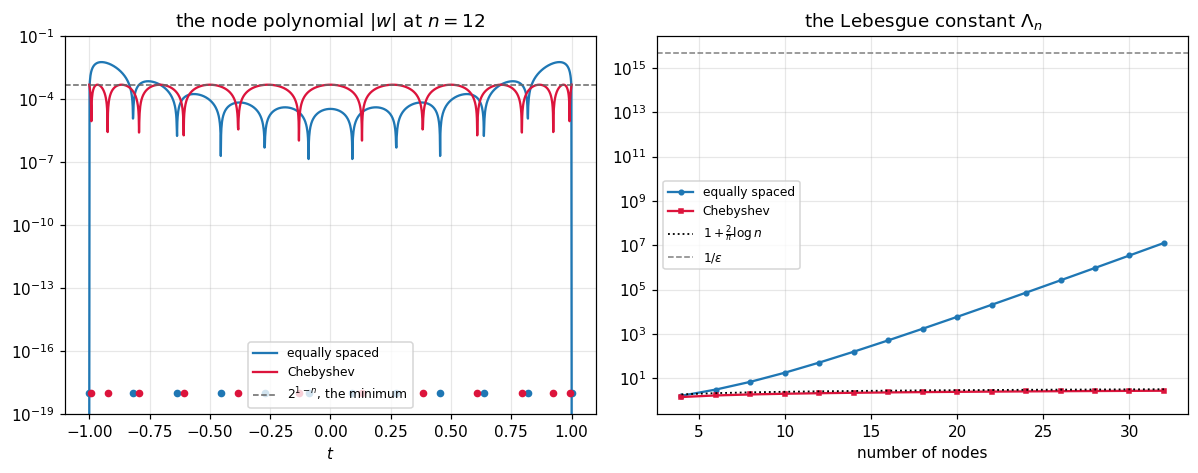

In [13]:
fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(11, 4.4))

n_pic = 12
fine = np.linspace(-1.0, 1.0, 1600)
eq = np.linspace(-1.0, 1.0, n_pic)
ch = cb.nodes(n_pic)
ax_left.semilogy(fine, np.abs(ie.node_polynomial(eq, fine)) + 1e-20,
                 lw=1.5, label="equally spaced")
ax_left.semilogy(fine, np.abs(ie.node_polynomial(ch, fine)) + 1e-20,
                 lw=1.5, color="crimson", label="Chebyshev")
ax_left.axhline(2.0 ** (1 - n_pic), color="0.4", ls="--", lw=1.0,
                label=r"$2^{1-n}$, the minimum")
ax_left.plot(eq, np.full_like(eq, 1e-18), "o", ms=4, color="tab:blue")
ax_left.plot(ch, np.full_like(ch, 1e-18), "o", ms=4, color="crimson")
ax_left.set_ylim(1e-19, 1e-1)
ax_left.set_title(f"the node polynomial $|w|$ at $n = {n_pic}$")
ax_left.set_xlabel("$t$")
ax_left.legend(fontsize=8, loc="lower center")

counts = np.arange(4, 33, 2)
eq_l, ch_l = [], []
for n in counts:
    eq_l.append(cb.lebesgue_constant(np.linspace(-1.0, 1.0, int(n))))
    ch_l.append(cb.lebesgue_constant(cb.nodes(int(n))))
ax_right.semilogy(counts, eq_l, "o-", ms=3, label="equally spaced")
ax_right.semilogy(counts, ch_l, "s-", ms=3, color="crimson", label="Chebyshev")
ax_right.semilogy(counts, 1.0 + 2.0 / np.pi * np.log(counts), "k:", lw=1.2,
                  label=r"$1 + \frac{2}{\pi}\log n$")
ax_right.axhline(1.0 / np.finfo(float).eps, color="0.5", ls="--", lw=1.0,
                 label=r"$1/\varepsilon$")
ax_right.set_title(r"the Lebesgue constant $\Lambda_n$")
ax_right.set_xlabel("number of nodes")
ax_right.legend(fontsize=8)

fig.tight_layout()
plt.show()

The left panel is the theorem: the red curve equioscillates between $\pm 2^{1-n}$ and the blue one
towers over it near the ends. The right panel is the consequence: one grows like $1.68^n$ and the
other like $\log n$, and that is the difference between a method that works at degree 60 and one
that does not.

## 9. Exercises

**Level 1, conceptual**

1.1 The Chebyshev nodes cluster toward the ends of the interval. Explain why that is the right
place for them, using lesson 46's node polynomial.

1.2 A colleague computes Chebyshev polynomials from their power form coefficients and reports
poor accuracy at degree 30. Explain what went wrong and give two better ways.

1.3 The Lebesgue constant is described here as a condition number. Say precisely what problem it
is the condition number of, and what its inputs and outputs are.

**Level 2, mathematical**

2.1 Prove the minimax theorem: among monic polynomials of degree $n$ on $[-1,1]$, $T_n/2^{n-1}$
uniquely minimises the maximum absolute value, which is $2^{1-n}$. Use the equioscillation to
build the contradiction.

2.2 Prove $T_k(\cos\theta) = \cos k\theta$ from the recurrence, and deduce the roots, the extrema
and the bound $|T_k| \le 1$.

2.3 Derive the change of interval formula and prove that the minimax value on $[a,b]$ is
$2^{1-n}\left(\frac{b-a}{2}\right)^n$.

2.4 Prove the Lebesgue bound $\|f - p\| \le (1 + \Lambda_n)\|f - p^{\text{best}}\|$.

2.5 State the asymptotic growth of the Lebesgue constant for both node families, and explain
where the $2/\pi$ comes from.

**Level 3, computational**

3.1 Implement Chebyshev interpolation using the **fast cosine transform** on Lobatto points, so
that the coefficients cost $O(n \log n)$, and compare against the barycentric route.

3.2 Implement a **Chebfun style** adaptive constructor that doubles the degree until the
coefficients fall to machine precision, and test it on functions of varying smoothness.

3.3 Implement **Chebyshev differentiation**, by differentiating the interpolant, and measure its
accuracy against the degree. Explain the conditioning you observe.

**Level 4, experimental**

4.1 Measure the Lebesgue constant for both node families over a wide range of $n$, fit each to
its predicted form, and find where the equally spaced constant crosses $1/\varepsilon$.

4.2 Measure the convergence rate of Chebyshev interpolation against the smoothness of $f$, using
a family of functions with a controlled number of derivatives, and fit the relationship.

4.3 Measure the accuracy of Chebyshev interpolation on a function with a pole at distance $d$
from the interval, fit the geometric rate, and compare with the Bernstein ellipse prediction.

**Level 5, advanced**

5.1 **The Bernstein ellipse.** The convergence rate of Chebyshev interpolation is governed by the
largest ellipse with foci at $\pm1$ inside which $f$ is analytic. State the result, and use it to
predict the rates measured in 4.3.

5.2 **Chebyshev nodes are not optimal for the Lebesgue constant.** They are optimal for the node
polynomial. Identify what node family does minimise $\Lambda_n$, say how much better it is, and
explain why nobody uses it.

5.3 **Why Chebyshev interpolation is the basis of a whole system.** Chebfun represents every
function by a Chebyshev interpolant and then does calculus on the representation. Describe what
operations become easy, which become hard, and what breaks.

## 10. Key takeaways

- **The minimax theorem** is the whole lesson: among monic degree $n$ polynomials on $[-1,1]$,
  $T_n/2^{n-1}$ has the smallest maximum, exactly $2^{1-n}$. Measured agreement: $10^{-15}$.

- **Chebyshev nodes beat everything offered**, including the best of 300 random node sets at
  every degree tested, and equally spaced nodes by a factor growing to 22.7 at fourteen nodes.

- **Two ways to compute $T_k$**, the recurrence and $\cos(k\arccos t)$, agreeing to $10^{-15}$.
  The power form is for looking at, not for evaluating.

- **The change of interval costs $((b-a)/2)^n$**, which is the quantitative argument for
  subdividing rather than raising the degree.

- **The Lebesgue constant explains lesson 46's second failure.** Equally spaced grows like
  $1.676^n$; Chebyshev like $0.6326\log n$ against the theoretical $2/\pi = 0.6366$. At twenty
  nodes the ratio is 2406.

- **Chebyshev interpolation of $\exp$ reaches $10^{-16}$ near 14 nodes and stays there to 60**,
  where equally spaced climbs thirteen orders of magnitude.

- **The barycentric weights are free**, in closed form, $O(n)$ and bounded by 1, so the whole
  construction is linear in the degree.

- **It does not fix a rough function.** On $|t|$ the error falls only like $1/n$, because there
  is no smoothness to exploit, and the fix there is a knot at the kink and lesson 51.

## Where this goes next

Lessons 48 and 49 go back to equally spaced data, which is what a printed table or a sensor gives
you, and develop the operator algebra that makes it workable at low order. Lessons 50 and 51 take
the other route out of lesson 46: keep the degree at 3 and add pieces. Part 8 returns to
Chebyshev, where the same polynomials give the best approximation rather than the interpolant.